# Mini-Project 3: Deep Learning for Computer Vision

## 1. Introduction

In this project, the **YOLOv8** deep learning architecture is used for object detection. YOLO (You Only Look Once) is a fast and efficient single-stage detector that processes the entire image in a single forward pass and predicts object locations along with their class labels.

In this implementation, two pretrained variants of the YOLOv8 architecture, namely **YOLOv8n** (nano version) and **YOLOv8s** (small version), are used to perform object detection and compare their performance.

Detection is performed on a coffee image obtained from the skimage dataset. The image is processed using pretrained YOLOv8 models, and the outputs from both architectures are analysed and compared.

## 2. Install Ultralytics YOLOv8

In [1]:
# Install the Ultralytics YOLOv8 library
!pip install -q ultralytics

## 3. Import Libraries

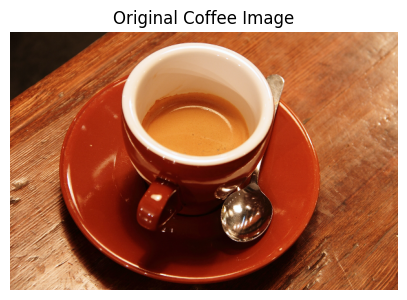

In [2]:
from skimage.data import coffee
from skimage.io import imsave
import matplotlib.pyplot as plt
import os

# Create folder
os.makedirs("images", exist_ok=True)

# Load images
coffee_img = coffee()

# Display image
plt.figure(figsize=(5,5))
plt.imshow(coffee_img)
plt.title("Original Coffee Image")
plt.axis("off")
plt.show()

# Save images
imsave("images/coffee.jpg", coffee_img)

## 4.1 Detection using YOLOv8n

In [3]:
from ultralytics import YOLO

# Load pretrained YOLOv8n model (nano version = fast)
model_n = YOLO("yolov8n.pt")

# Run detection on the image
results_n = model_n("images/coffee.jpg", save=True)

# Display output
from IPython.display import Image, display
import glob, os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/images/coffee.jpg: 448x640 1 cup, 1 dining table, 93.4ms
Speed: 10.2ms preprocess, 93.4ms inference, 48.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


## 4.2 Detection using YOLOv8s

YOLOv8s is a larger variant of YOLOv8n with improved feature extraction capability. It provides better detection accuracy than YOLOv8n.

In [4]:
model_s = YOLO("yolov8s.pt")

results_s = model_s("images/coffee.jpg", save=True)


image 1/1 /content/images/coffee.jpg: 448x640 1 cup, 1 spoon, 1 dining table, 35.4ms
Speed: 1.7ms preprocess, 35.4ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-2


## 5. Model comparison section

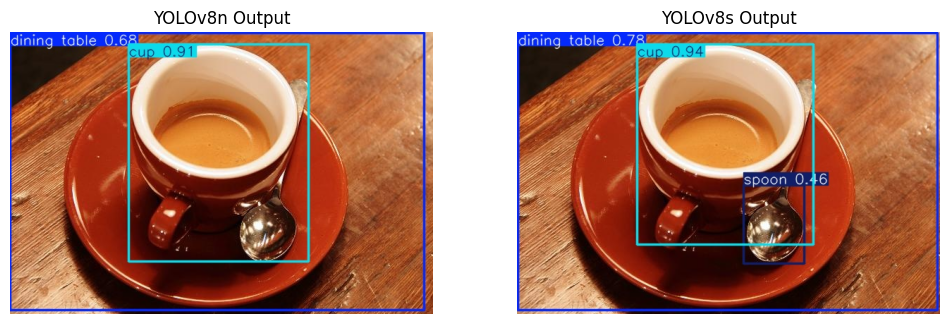

In [5]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Get last two prediction folders
predict_folders = sorted(glob.glob("runs/detect/predict*"))

folder_n = predict_folders[-2]
folder_s = predict_folders[-1]

img_n = mpimg.imread(os.path.join(folder_n, "coffee.jpg"))
img_s = mpimg.imread(os.path.join(folder_s, "coffee.jpg"))

# Plot side-by-side
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_n)
plt.title("YOLOv8n Output")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_s)
plt.title("YOLOv8s Output")
plt.axis("off")

plt.show()

Both YOLOv8n and YOLOv8s models were applied to the same coffee image.

YOLOv8n detected:
- Cup (confidence ≈ 0.91)
- Dining table (confidence ≈ 0.68)

YOLOv8s detected:
- Cup (confidence ≈ 0.94)
- Dining table (confidence ≈ 0.78)
- Spoon (confidence ≈ 0.46)

The YOLOv8s model successfully detected an additional object **(spoon)** and produced higher confidence scores compared to YOLOv8n. This demonstrates that increasing model size improves detection capability and accuracy.

## 6. Conclusion

In this project, object detection was implemented using pretrained **YOLOv8** deep learning models. Two variants, **YOLOv8n** and **YOLOv8s**, were evaluated on the same **coffee** image from the skimage dataset.

The results showed that **YOLOv8s** provided improved detection accuracy and detected additional object compared to YOLOv8n. This demonstrates the effectiveness of larger deep learning architectures for object detection tasks.